# MobileNetV3Small 3-Class Image Classification with Keras

This notebook trains a 3-class classifier using `MobileNetV3Small` transfer learning with the same center-crop or face detection preprocessing, reusable data pipeline, input-size tuning, and export flow as the other 3-class notebooks.


In [1]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.10.0
GPU available: True


In [2]:
SEED = 42
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 10
CENTER_CROP_FRACTION = 0.75
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
USE_FACE_CROP_DATASET = False
ORIGINAL_DATA_ROOT = Path('../data')
FACE_CROP_DATA_ROOT = Path('../data_face_crop_balanced')
DATA_ROOT = FACE_CROP_DATA_ROOT if USE_FACE_CROP_DATASET else ORIGINAL_DATA_ROOT
APPLY_CENTER_CROP = not USE_FACE_CROP_DATASET
MODEL_PATH = Path('saved_model/mobilenetv3small_3class_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())
print('Using face-cropped balanced dataset:', USE_FACE_CROP_DATASET)
print('Apply center crop preprocessing:', APPLY_CENTER_CROP)


Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data
Using face-cropped balanced dataset: False
Apply center crop preprocessing: True


In [3]:
def center_crop_array(array, crop_fraction=CENTER_CROP_FRACTION, image_size=IMAGE_SIZE):
    if not 0 < crop_fraction <= 1:
        raise ValueError('CENTER_CROP_FRACTION must be in the range (0, 1]')

    height, width = array.shape[:2]
    crop_height = max(1, int(height * crop_fraction))
    crop_width = max(1, int(width * crop_fraction))
    y0 = (height - crop_height) // 2
    x0 = (width - crop_width) // 2
    cropped = array[y0:y0 + crop_height, x0:x0 + crop_width]
    resized = tf.image.resize(cropped, image_size, method='bilinear')
    return resized.numpy().astype(np.float32)


def resize_array(array, image_size=IMAGE_SIZE):
    resized = tf.image.resize(array, image_size, method='bilinear')
    return resized.numpy().astype(np.float32)


def make_geometry_fn(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION, apply_center_crop=APPLY_CENTER_CROP):
    def geometry_fn(array):
        if apply_center_crop:
            return center_crop_array(array, crop_fraction=crop_fraction, image_size=image_size)
        return resize_array(array, image_size=image_size)
    return geometry_fn


def make_preprocess_fn(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION, apply_center_crop=APPLY_CENTER_CROP):
    geometry_fn = make_geometry_fn(image_size=image_size, crop_fraction=crop_fraction, apply_center_crop=apply_center_crop)

    def preprocess_fn(array):
        return preprocess_input(geometry_fn(array))

    return preprocess_fn


preprocess_final_input = make_preprocess_fn()


In [4]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())


,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074812_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130316_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


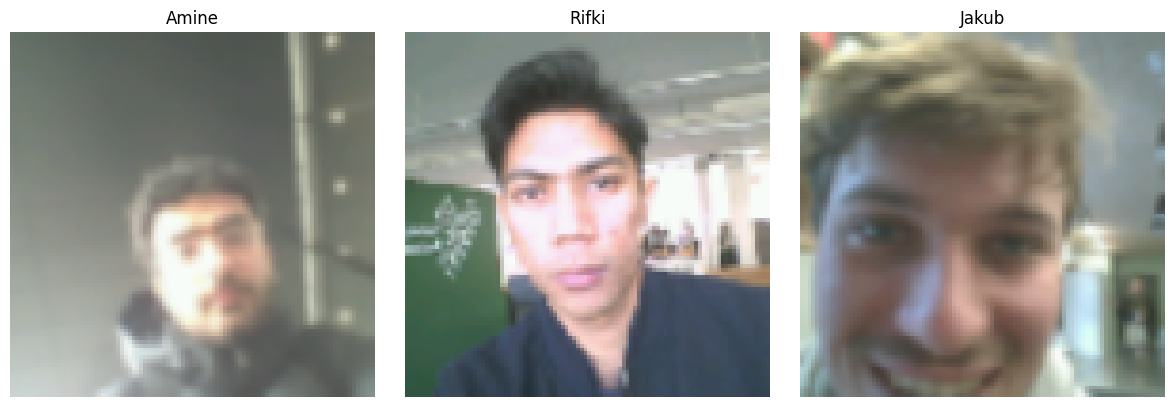

In [5]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    image_array = keras.utils.img_to_array(image)
    cropped_image = center_crop_array(image_array).astype(np.uint8)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(cropped_image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=VALIDATION_SPLIT,
    stratify=train_df['label'],
    random_state=SEED,
    shuffle=True,
)
train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print('Validation split counts:')
print(val_split_df['label'].value_counts().sort_index())


def make_data_generators(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION, apply_center_crop=APPLY_CENTER_CROP):
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction, apply_center_crop=apply_center_crop)

    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=12,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=(0.9, 1.1),
        horizontal_flip=True,
    )

    test_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_split_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True,
    )

    val_gen = train_datagen.flow_from_dataframe(
        dataframe=val_split_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=False,
    )

    test_gen = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = make_data_generators()
print('Class indices:', train_gen.class_indices)


Validation split counts:
label
Amine    144
Jakub    144
Rifki    144
Name: count, dtype: int64
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [7]:
def build_mobilenetv3small_model(config: dict, model_name: str = 'MobileNetV3Small_3Class') -> keras.Model:
    image_size = tuple(config.get('image_size', IMAGE_SIZE))
    alpha = float(config['alpha'])
    dropout = float(config['dropout'])
    dense_units = int(config['dense_units'])
    l2_strength = float(config['l2'])
    learning_rate = float(config['learning_rate'])
    regularizer = keras.regularizers.l2(l2_strength) if l2_strength else None

    base_model = MobileNetV3Small(
        include_top=False,
        weights='imagenet',
        input_shape=image_size + (3,),
        alpha=alpha,
    )
    base_model.trainable = False

    inputs = keras.Input(shape=image_size + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(
        dense_units,
        activation='relu',
        kernel_regularizer=regularizer,
    )(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(
        len(CLASS_NAMES),
        activation='softmax',
        kernel_regularizer=regularizer,
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def unfreeze_last_base_layers(model: keras.Model, trainable_layers: int):
    base_model = model.layers[1]
    base_model.trainable = True

    for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False

    return base_model


## Hyperparameter Tuning

Run this section before final training to compare MobileNetV3Small classifier-head settings, width multiplier, and input size on the same center-crop preprocessing pipeline.


In [8]:
TUNING_EPOCHS = 5

TUNING_CONFIGS = [
    {'image_size': (96, 96), 'crop_fraction': 0.8, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (128, 128), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (160, 160), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (128, 128), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (160, 160), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (160, 160), 'crop_fraction': 0.70, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 1e-4, 'learning_rate': 5e-4, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 1e-4, 'learning_rate': 5e-4, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-5},
    
]


tuning_results = []
for run_id, config in enumerate(TUNING_CONFIGS, start=1):
    print(f'\nTuning run {run_id}/{len(TUNING_CONFIGS)}: {config}')
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    tuning_train_gen, tuning_val_gen, _ = make_data_generators(
        image_size=tuple(config['image_size']),
        crop_fraction=float(config['crop_fraction']),
        apply_center_crop=APPLY_CENTER_CROP,
    )
    tuning_model = build_mobilenetv3small_model(config, model_name=f'MobileNetV3Small_3Class_Tuning_{run_id}')
    print('Model summary before training:')
    tuning_model.summary()
    tuning_history = tuning_model.fit(
        tuning_train_gen,
        validation_data=tuning_val_gen,
        epochs=TUNING_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ],
        verbose=1,
    )

    best_val_accuracy = max(tuning_history.history['val_accuracy'])
    best_val_loss = min(tuning_history.history['val_loss'])
    tuning_results.append({
        'run_id': run_id,
        **config,
        'image_size': f'{config["image_size"][0]}x{config["image_size"][1]}',
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'epochs_run': len(tuning_history.history['loss']),
    })


tuning_df = pd.DataFrame(tuning_results).sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True],
).reset_index(drop=True)

display(tuning_df)
best_config = tuning_df.iloc[0].to_dict()
best_config['image_size'] = tuple(int(part) for part in best_config['image_size'].split('x'))
print('Best config:')
print(best_config)



Tuning run 1/8: {'image_size': (96, 96), 'crop_fraction': 0.8, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 0.001, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-05}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model summary before training:
Model: "MobileNetV3Small_3Class_Tuning_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 MobilenetV3small (Functiona  (None, 3, 3, 432)        583160    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 432)              0         
 lobalAver

,run_id,image_size,crop_fraction,alpha,dropout,dense_units,l2,learning_rate,fine_tune_layers,fine_tune_learning_rate,best_val_accuracy,best_val_loss,epochs_run
0,8,192x192,0.75,1.00,0.3,160,0.0001,0.0005,30,0.00001,0.988426,0.087637,5
1,3,160x160,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.979167,0.078015,5
2,5,160x160,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.979167,0.078015,5
3,7,160x160,0.70,1.00,0.3,160,0.0001,0.0005,30,0.00001,0.979167,0.109713,5
4,1,96x96,0.80,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.972222,0.092659,5
5,6,192x192,0.75,0.75,0.3,128,0.0000,0.0010,20,0.00001,0.972222,0.106271,5
6,4,128x128,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.969907,0.084793,5
7,2,128x128,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.969907,0.084793,5


Best config:
{'run_id': 8, 'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 0.0001, 'learning_rate': 0.0005, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-05, 'best_val_accuracy': 0.9884259104728699, 'best_val_loss': 0.08763745427131653, 'epochs_run': 5}


In [9]:
USE_BEST_TUNING_CONFIG = False

DEFAULT_FINAL_CONFIG = {
    'image_size': IMAGE_SIZE,
    'crop_fraction': CENTER_CROP_FRACTION,
    'alpha': 0.75,
    'dropout': 0.2,
    'dense_units': 64,
    'l2': 0.0001,
    'learning_rate': 1e-3,
    'fine_tune_layers': 20,
    'fine_tune_learning_rate': 1e-5,
}

FINAL_CONFIG = dict(DEFAULT_FINAL_CONFIG)
if USE_BEST_TUNING_CONFIG and 'best_config' in globals():
    FINAL_CONFIG.update({
        'image_size': tuple(best_config['image_size']),
        'crop_fraction': float(best_config['crop_fraction']),
        'alpha': float(best_config['alpha']),
        'dropout': float(best_config['dropout']),
        'dense_units': int(best_config['dense_units']),
        'l2': float(best_config['l2']),
        'learning_rate': float(best_config['learning_rate']),
        'fine_tune_layers': int(best_config['fine_tune_layers']),
        'fine_tune_learning_rate': float(best_config['fine_tune_learning_rate']),
    })

print('Final training config:', FINAL_CONFIG)
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

IMAGE_SIZE = tuple(FINAL_CONFIG['image_size'])
preprocess_final_input = make_preprocess_fn(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
    apply_center_crop=APPLY_CENTER_CROP,
)
train_gen, val_gen, test_gen = make_data_generators(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
    apply_center_crop=APPLY_CENTER_CROP,
)

model = build_mobilenetv3small_model(FINAL_CONFIG)
model.summary()


Final training config: {'image_size': (96, 96), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 64, 'l2': 0.0001, 'learning_rate': 0.001, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-05}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model: "MobileNetV3Small_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 MobilenetV3small (Functiona  (None, 3, 3, 432)        583160    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 432)              0         
 lobalAveragePooling2D)                  

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)


Epoch 1/5
108/108 [==============================] - 26s 200ms/step - loss: 0.7031 - accuracy: 0.6979 - val_loss: 0.3132 - val_accuracy: 0.9097 - lr: 0.0010
Epoch 2/5
108/108 [==============================] - 12s 113ms/step - loss: 0.3437 - accuracy: 0.8669 - val_loss: 0.2099 - val_accuracy: 0.9213 - lr: 0.0010
Epoch 3/5
108/108 [==============================] - 15s 139ms/step - loss: 0.2833 - accuracy: 0.8929 - val_loss: 0.1895 - val_accuracy: 0.9375 - lr: 0.0010
Epoch 4/5
108/108 [==============================] - 22s 208ms/step - loss: 0.2227 - accuracy: 0.9190 - val_loss: 0.1629 - val_accuracy: 0.9398 - lr: 0.0010
Epoch 5/5
108/108 [==============================] - 21s 199ms/step - loss: 0.2006 - accuracy: 0.9346 - val_loss: 0.1493 - val_accuracy: 0.9537 - lr: 0.0010


In [11]:
unfreeze_last_base_layers(model, trainable_layers=FINAL_CONFIG['fine_tune_layers'])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINAL_CONFIG['fine_tune_learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)


Epoch 1/10
108/108 [==============================] - 28s 216ms/step - loss: 0.1938 - accuracy: 0.9363 - val_loss: 0.1404 - val_accuracy: 0.9514 - lr: 1.0000e-05
Epoch 2/10
108/108 [==============================] - 23s 209ms/step - loss: 0.1809 - accuracy: 0.9340 - val_loss: 0.1429 - val_accuracy: 0.9468 - lr: 1.0000e-05
Epoch 3/10
108/108 [==============================] - 23s 213ms/step - loss: 0.1624 - accuracy: 0.9491 - val_loss: 0.1281 - val_accuracy: 0.9606 - lr: 1.0000e-05
Epoch 4/10
108/108 [==============================] - 22s 207ms/step - loss: 0.1635 - accuracy: 0.9427 - val_loss: 0.1058 - val_accuracy: 0.9745 - lr: 1.0000e-05
Epoch 5/10
108/108 [==============================] - 26s 243ms/step - loss: 0.1559 - accuracy: 0.9462 - val_loss: 0.1107 - val_accuracy: 0.9514 - lr: 1.0000e-05
Epoch 6/10
108/108 [==============================] - 25s 232ms/step - loss: 0.1701 - accuracy: 0.9410 - val_loss: 0.1043 - val_accuracy: 0.9722 - lr: 1.0000e-05
Epoch 7/10
108/108 [========

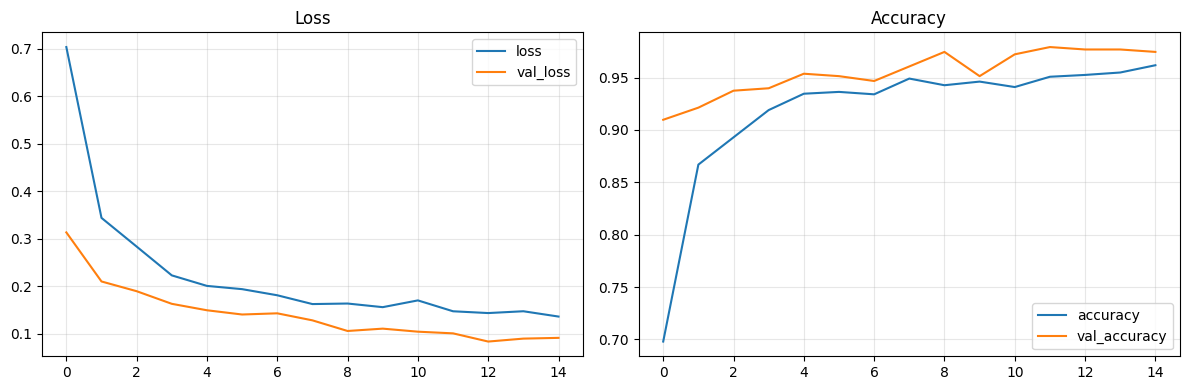

In [12]:
history = {}
for key in history_head.history:
    history[key] = history_head.history[key] + history_finetune.history[key]

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Test loss: 0.2820
Test accuracy: 0.9333

              precision    recall  f1-score   support

       Amine       0.96      0.89      0.93       180
       Rifki       0.94      0.99      0.96       180
       Jakub       0.90      0.92      0.91       180

    accuracy                           0.93       540
   macro avg       0.93      0.93      0.93       540
weighted avg       0.93      0.93      0.93       540



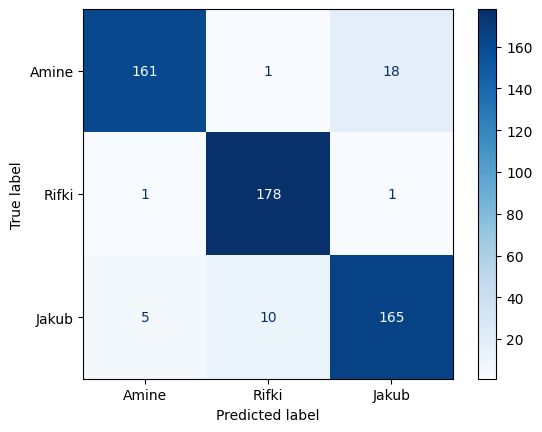

In [13]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()


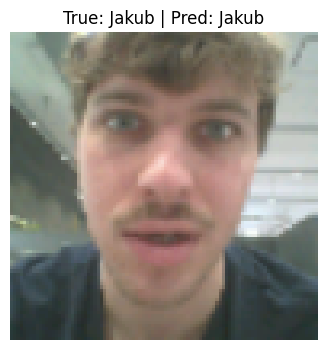

Amine: 0.0003
Rifki: 0.0006
Jakub: 0.9990

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\mobilenetv3small_3class_classifier.keras


In [14]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
array = keras.utils.img_to_array(image)
preview_image = make_geometry_fn(image_size=IMAGE_SIZE, crop_fraction=FINAL_CONFIG['crop_fraction'], apply_center_crop=APPLY_CENTER_CROP)(array).astype(np.uint8)
array = preprocess_final_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(preview_image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print()
print('Saved model to:', MODEL_PATH.resolve())


## Export Training Subset

This section saves the preprocessed training subset used by MobileNetV3Small to `saved_model/x_train_mobilenetv3small.npy` and `saved_model/y_train_mobilenetv3small.npy` for later quantization.


In [15]:
FINAL_IMAGE_SIZE = tuple(globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE))
FINAL_CROP_FRACTION = float(globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
X_TRAIN_PATH = MODEL_PATH.parent / f'x_train_mobilenetv3small_{FINAL_IMAGE_SIZE[0]}.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / f'y_train_mobilenetv3small_{FINAL_IMAGE_SIZE[0]}.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    return train_split_df.reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    preprocess_fn = make_preprocess_fn(image_size=FINAL_IMAGE_SIZE, crop_fraction=FINAL_CROP_FRACTION, apply_center_crop=APPLY_CENTER_CROP)

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=FINAL_IMAGE_SIZE, keep_aspect_ratio=True)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_fn(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Export image size: {FINAL_IMAGE_SIZE}')
print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')


Export image size: (96, 96)
Saved training subset: 1728 images
x_train shape: (1728, 96, 96, 3)
y_train shape: (1728,)
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\x_train_mobilenetv3small_96.npy
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\y_train_mobilenetv3small_96.npy


## Quantization

Export the trained MobileNetV3Small model to full INT8 TensorFlow Lite, generate C/H artifacts, and evaluate the quantized model using the same center-crop preprocessing and selected final input size.


In [16]:
import os
from utils.export_tflite import write_model_c_file, write_model_h_file

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

SCRIPT_DIR = Path.cwd()
QUANTIZED_MODEL_DIR = SCRIPT_DIR / 'quantized_model'
GEN_DIR = SCRIPT_DIR / 'gen'
KERAS_MODEL_PATH = MODEL_PATH
EXPORT_IMAGE_SIZE = tuple(globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE))
CALIBRATION_DATA_PATH = MODEL_PATH.parent / f'x_train_mobilenetv3small_{EXPORT_IMAGE_SIZE[0]}.npy'
MOBILENETV3_TFLITE_MODEL_PATH = QUANTIZED_MODEL_DIR / 'mobilenetv3small_3class_int8.tflite'
MOBILENETV3_MODEL_C_PATH = GEN_DIR / 'mobilenetv3small_model.c'
MOBILENETV3_MODEL_H_PATH = GEN_DIR / 'mobilenetv3small_model.h'
REPRESENTATIVE_DATASET_SAMPLES = None
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print('Keras model:', KERAS_MODEL_PATH.resolve())
print('Calibration data:', CALIBRATION_DATA_PATH.resolve())
print('TFLite output:', MOBILENETV3_TFLITE_MODEL_PATH.resolve())


Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\mobilenetv3small_3class_classifier.keras
Calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\x_train_mobilenetv3small_96.npy
TFLite output: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\quantized_model\mobilenetv3small_3class_int8.tflite


In [17]:
def representative_indices(y_train: np.ndarray, max_samples = REPRESENTATIVE_DATASET_SAMPLES) -> np.ndarray:
    if y_train.ndim != 1:
        raise ValueError(f'Expected 1D labels, got shape {y_train.shape}')
    if len(y_train) == 0:
        raise ValueError('Representative dataset requires at least one sample.')
    if max_samples is None or max_samples <= 0 or max_samples >= len(y_train):
        return np.arange(len(y_train), dtype=np.int32)

    classes = np.unique(y_train)
    per_class = max(1, max_samples // len(classes))
    selected = []
    for class_id in classes:
        class_indices = np.flatnonzero(y_train == class_id)
        take = min(len(class_indices), per_class)
        if take == len(class_indices):
            selected.extend(class_indices.tolist())
        else:
            chosen = np.linspace(0, len(class_indices) - 1, num=take, dtype=np.int32)
            selected.extend(class_indices[chosen].tolist())

    if len(selected) < min(max_samples, len(y_train)):
        remaining = np.setdiff1d(np.arange(len(y_train), dtype=np.int32), np.array(selected, dtype=np.int32), assume_unique=False)
        needed = min(max_samples, len(y_train)) - len(selected)
        if needed > 0 and len(remaining) > 0:
            chosen = np.linspace(0, len(remaining) - 1, num=min(needed, len(remaining)), dtype=np.int32)
            selected.extend(remaining[chosen].tolist())

    return np.array(sorted(set(selected)), dtype=np.int32)


def export_model_to_tflite(model: keras.Model, x_train: np.ndarray, y_train: np.ndarray) -> bytes:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    def representative_dataset():
        for i in representative_indices(y_train):
            yield [x_train[i:i + 1].astype(np.float32)]

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.experimental_new_quantizer = True
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


def resolve_model_img_size(model: keras.Model) -> int:
    input_shape = model.input_shape[0] if isinstance(model.input_shape, list) else model.input_shape
    if len(input_shape) != 4:
        raise ValueError(f'Expected 4D model input shape, got {input_shape}')

    height, width, channels = input_shape[1:]
    if None in (height, width, channels):
        raise ValueError(f'Model input shape must be fully defined, got {input_shape}')
    if channels != 3 or height != width:
        raise ValueError(f'Expected square RGB input, got {input_shape}')
    return int(height)


def export_artifacts(tflite_model: bytes, img_size: int):
    QUANTIZED_MODEL_DIR.mkdir(exist_ok=True)
    GEN_DIR.mkdir(exist_ok=True)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    defines = {
        'IMG_SIZE': img_size,
        'NUM_CLASSES': NUM_CLASSES,
        'INPUT_SCALE': f'{input_scale}f',
        'INPUT_ZERO_POINT': input_zero_point,
        'OUTPUT_SCALE': f'{output_scale}f',
        'OUTPUT_ZERO_POINT': output_zero_point,
    }
    declarations = [
        f'// Labels: {", ".join(f"{name}={idx}" for name, idx in CLASS_TO_INDEX.items())}',
    ]

    MOBILENETV3_TFLITE_MODEL_PATH.write_bytes(tflite_model)
    write_model_h_file(MOBILENETV3_MODEL_H_PATH, defines, declarations)
    write_model_c_file(MOBILENETV3_MODEL_C_PATH, tflite_model)

    print(f'Input scale:       {input_scale}')
    print(f'Input zero point:  {input_zero_point}')
    print(f'Output scale:      {output_scale}')
    print(f'Output zero point: {output_zero_point}')
    print(f'Model size:        {len(tflite_model) / 1024:.1f} KB')
    print(f'Saved: {MOBILENETV3_TFLITE_MODEL_PATH}')
    print(f'Saved: {MOBILENETV3_MODEL_C_PATH}')
    print(f'Saved: {MOBILENETV3_MODEL_H_PATH}')


def load_image_array(image_path: Path, image_size=None) -> np.ndarray:
    if image_size is None:
        image_size = tuple(globals().get('QUANT_IMAGE_SIZE', globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE)))
    crop_fraction = globals().get('QUANT_CROP_FRACTION', globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction, apply_center_crop=APPLY_CENTER_CROP)
    image = keras.utils.load_img(image_path, target_size=image_size, keep_aspect_ratio=True)
    array = keras.utils.img_to_array(image).astype(np.float32)
    return preprocess_fn(array)


def load_test_split(data_root: Path, image_size=None):
    if image_size is None:
        image_size = tuple(globals().get('QUANT_IMAGE_SIZE', globals().get('FINAL_CONFIG', {}).get('image_size', IMAGE_SIZE)))
    x_test, y_test = [], []
    for class_name in CLASS_NAMES:
        split_dir = data_root / class_name / 'test'
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing test split: {split_dir.resolve()}')

        for image_path in sorted(split_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}:
                x_test.append(load_image_array(image_path, image_size=image_size))
                y_test.append(CLASS_TO_INDEX[class_name])

    if not x_test:
        raise ValueError(f'No test images found under {data_root.resolve()}')
    return np.stack(x_test).astype(np.float32), np.array(y_test, dtype=np.int32)


def load_tflite_interpreter(model_path: Path):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    return interpreter, interpreter.get_input_details()[0], interpreter.get_output_details()[0]


def resize_to_tflite_input(images: np.ndarray, input_details: dict) -> np.ndarray:
    input_shape = tuple(input_details['shape'])
    expected_shape = tuple(input_shape[1:])
    if input_shape[0] != 1 or input_shape[3] != 3:
        raise ValueError(f'Unexpected model input shape: {input_shape}')
    if images.shape[1:] == expected_shape:
        return images
    return tf.image.resize(images, input_shape[1:3], method='bilinear').numpy().astype(np.float32)


def predict_tflite(interpreter, input_details, output_details, images: np.ndarray) -> np.ndarray:
    if input_details['dtype'] != np.int8:
        raise ValueError(f'Expected int8 input tensor, got {input_details["dtype"]}')

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    quantized_images = images / input_scale + input_zero_point
    quantized_images = np.clip(quantized_images, -128, 127).astype(np.int8)

    raw_predictions = np.empty((len(images), NUM_CLASSES), dtype=np.int8)
    for i, image in enumerate(quantized_images):
        interpreter.set_tensor(input_details['index'], image[None, ...])
        interpreter.invoke()
        raw_predictions[i] = interpreter.get_tensor(output_details['index'])[0]

    return (raw_predictions.astype(np.float32) - output_zero_point) * output_scale


### Export INT8 TFLite Model


In [18]:
if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(f'Model not found: {KERAS_MODEL_PATH.resolve()}')
if not CALIBRATION_DATA_PATH.exists():
    raise FileNotFoundError(f'Calibration data not found: {CALIBRATION_DATA_PATH.resolve()}')

print(f'Loading Keras model: {KERAS_MODEL_PATH.resolve()}')
quant_model = keras.models.load_model(KERAS_MODEL_PATH)
img_size = resolve_model_img_size(quant_model)
QUANT_IMAGE_SIZE = (img_size, img_size)
QUANT_CROP_FRACTION = float(globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
print(f'Quantization image size: {QUANT_IMAGE_SIZE}')
print(f'Quantization crop fraction: {QUANT_CROP_FRACTION}')

print(f'Loading calibration data: {CALIBRATION_DATA_PATH.resolve()}')
x_train_quant = np.load(CALIBRATION_DATA_PATH)
y_train_quant = np.load(MODEL_PATH.parent / f'y_train_mobilenetv3small_{EXPORT_IMAGE_SIZE[0]}.npy')
if x_train_quant.ndim != 4:
    raise ValueError(f'Expected x_train to be 4D, got shape {x_train_quant.shape}')
if y_train_quant.ndim != 1:
    raise ValueError(f'Expected y_train to be 1D, got shape {y_train_quant.shape}')
if len(y_train_quant) != len(x_train_quant):
    raise ValueError('Calibration images and labels must have the same length')
if x_train_quant.shape[1:] != (img_size, img_size, 3):
    raise ValueError(f'Calibration data shape {x_train_quant.shape} does not match model input size {img_size}')

tflite_model = export_model_to_tflite(quant_model, x_train_quant, y_train_quant)
export_artifacts(tflite_model, img_size)


Loading Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\mobilenetv3small_3class_classifier.keras
Quantization image size: (96, 96)
Quantization crop fraction: 0.75
Loading calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\saved_model\x_train_mobilenetv3small_96.npy


c:\Users\Rifki\.conda\envs\TF\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Input scale:       1.0
Input zero point:  -128
Output scale:      0.00390625
Output zero point: -128
Model size:        841.5 KB
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\quantized_model\mobilenetv3small_3class_int8.tflite
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\gen\mobilenetv3small_model.c
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\gen\mobilenetv3small_model.h


### Evaluate Quantized TFLite Model


In [19]:
if not MOBILENETV3_TFLITE_MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing quantized model: {MOBILENETV3_TFLITE_MODEL_PATH}')
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Missing data root: {DATA_ROOT.resolve()}')

x_test_quant, y_test_quant = load_test_split(DATA_ROOT)
interpreter, input_details, output_details = load_tflite_interpreter(MOBILENETV3_TFLITE_MODEL_PATH)
x_test_quant = resize_to_tflite_input(x_test_quant, input_details)

quant_predictions = predict_tflite(interpreter, input_details, output_details, x_test_quant)
y_pred_quant = np.argmax(quant_predictions, axis=1)
quant_accuracy = np.mean(y_pred_quant == y_test_quant)
quant_cm = confusion_matrix(y_test_quant, y_pred_quant)

print(f'Model: {MOBILENETV3_TFLITE_MODEL_PATH}')
print(f'Test samples: {len(x_test_quant)}')
print(f'Quantized accuracy: {quant_accuracy:.4f}')
print()
print('Classification report:')
print(classification_report(y_test_quant, y_pred_quant, target_names=CLASS_NAMES, digits=4))
print('Confusion matrix:')
print(quant_cm)


Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\ModelExploration\quantized_model\mobilenetv3small_3class_int8.tflite
Test samples: 540
Quantized accuracy: 0.5500

Classification report:
              precision    recall  f1-score   support

       Amine     0.9538    0.3444    0.5061       180
       Rifki     0.4500    1.0000    0.6207       180
       Jakub     0.7333    0.3056    0.4314       180

    accuracy                         0.5500       540
   macro avg     0.7124    0.5500    0.5194       540
weighted avg     0.7124    0.5500    0.5194       540

Confusion matrix:
[[ 62  98  20]
 [  0 180   0]
 [  3 122  55]]


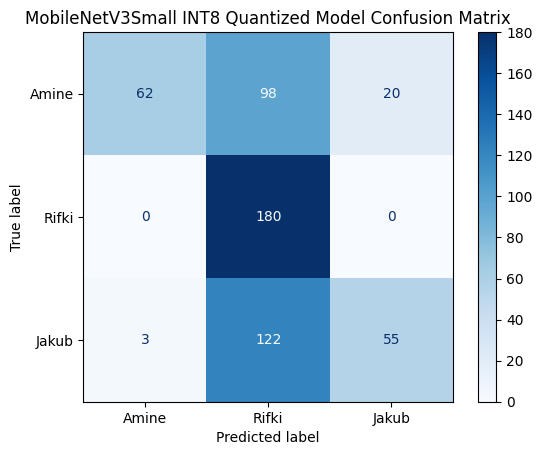

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix=quant_cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title('MobileNetV3Small INT8 Quantized Model Confusion Matrix')
plt.show()
